In [1]:
import sys

import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group


from collections import OrderedDict

import matplotlib as mpl

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
dataset = datasets.construct("imagenet-butterfly")

In [6]:
# ds_train, _ = random_split(, [0.5, 0.5])
ds_train = dataset.create_subset(train_split=True)
ds_val = dataset.create_subset(train_split=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|█████████████████████████████████████████████████████████████████████████| 7800/7800 [00:00<00:00, 2357029.63it/s]


We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 807632.35it/s]


In [7]:
MODEL_NAME = "imagenet-vitb-tv"
GAMMA = 1e-1

In [8]:
teacher = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(teacher, dataset.selected_classes)

teacher.to(device);

In [9]:
teacher_acc, _ = metrics.accuracy(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_classes=dataset.num_classes,
    device=device,
)
teacher_acc

0.9733333587646484

In [10]:
!nvidia-smi

Thu Sep 19 04:50:49 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.54.03              Driver Version: 535.54.03    CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:06:00.0 Off |                    0 |
| N/A   43C    P0              61W / 250W |  18570MiB / 40960MiB |     24%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [11]:
from torchvision import transforms as T
from xaikd import vitlrp
input_transform = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [12]:
from torch import nn
from xaikd import datasets
from torch.utils.data import Dataset, DataLoader

def extract_activation_context(
    model: nn.Module,
    layer: str,
    dataset: datasets.DatasetConfiguration,
    data_loader: DataLoader,
    logit_modifier,
    rng: np.random.Generator,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
):
    arr_act = []
    arr_ctx = []

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )
        low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

        composite = vitlrp._build_composite(
            lb=low, hb=high, gamma=GAMMA, eps=1e-6
        )

        
        with Gradient(model=model, composite=composite) as attributor:
            for bix, batch in tqdm(enumerate(data_loader)):
                # if bix < 61:
                #     continue
                x, y = batch
                x = x.to(device)

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))
                
                act = utils.interceptor.get_output(module)

                assert act.grad is not None
                rel = act.grad

                output_dimensions = act.shape[1:]

                ctx = torch.where(act.abs() > 0, rel / act, 0)

                if torch.isnan(rel).any():
                    print("Found `nan` from `relevance`; skip")
                    for i in range(ctx.shape[0]):
                        count_nans = torch.isnan(rel).sum()
                        if count_nans > 0:
                            print(f"i={i}: {count_nans}")
                    raise
                    continue
                
                if strict_mode:
                    np.testing.assert_allclose(
                        (act * ctx).detach().cpu().numpy(),
                        rel.detach().cpu().numpy(),
                        atol=1e-6,
                    )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx
    
def get_act_ctx(model, dataset, layer, gamma=0.25, eps=1e-6, verbose=False):

    logit_modifier = attributors.WinningClassEvidence(num_classes=len(dataset.selected_classes))
    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False,
    )
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        strict_mode=True
    )


MAIN_LAYER = "encoder.layers.8"

_arr_act, _arr_ctx = get_act_ctx(teacher, dataset, layer=MAIN_LAYER, verbose=False)

122it [09:10,  4.51s/it]


encoder.layers.8: output-dims=torch.Size([768, 197, 1])


In [13]:
def compute_accuracy_with_Uk(
    model, layer, Uk, dataset, dl
):
    module = utils.interceptor.get_module(model, layer)

    UUT, hook_func = fh_low_rank(Uk)
    hook = module.register_forward_hook(hook_func)

    try:
        acc, _ = metrics.accuracy(
                        model,
                        dataloader=dl,
                        num_classes=dataset.num_classes,
                        device=device,
                )
        
    finally:
        hook.remove()
        del UUT

    
    return acc  

In [14]:
def ano():
    
    out = teacher.encoder.layers[8](torch.randn(2, 768, 197, 1).to(device))
    return out.shape
ano()

torch.Size([2, 768, 197, 1])

In [15]:

def fh_low_rank(U):
    d, k = U.shape

    assert k <= d

    UUT = U @ U.T 
    assert UUT.shape == (d, d)

    UUT = torch.from_numpy(UUT).float().unsqueeze(2).unsqueeze(3).to(device)
    
    def do(module, inp, out):
        inp, = inp

        assert out.shape[1:] == (768, 197, 1), f"{out.shape}"
        
        out2 = F.conv2d(out, UUT)

        if k == d and False:
            np.testing.assert_allclose(
                out.detach().cpu().numpy(), out2.detach().cpu().numpy(),
                atol=1e-3
            )

        
        return out2

    return UUT, do 

In [16]:
np.isnan(_arr_ctx).any(), np.isnan(_arr_act).any()

(False, False)

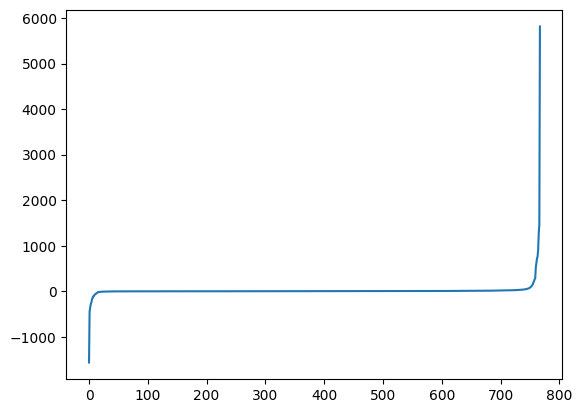

In [17]:
def ano():
    
    arr_act = _arr_act
    arr_ctx = _arr_ctx
    
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
    
    eigvals, eigvecs = np.linalg.eigh(ccov)
    
    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    plt.plot(eigvals)
ano()

In [18]:
def estimate_basis(layer, basis_name, k):

    
    arr_act = _arr_act
    arr_ctx = _arr_ctx

    _, d = arr_act.shape

    if basis_name == "pca":
        _, pca_eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
        U = np.flip(pca_eigvecs, axis=1).copy()
        return U[:, :k].copy()

    elif basis_name == "prca-sortabs":
        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-np.abs(eigvals))

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()

    else:
        raise

@torch.no_grad()
def compute_accuracy_of_basis_at_k(
    model, dataset, layer, 
    arr_ks,
    arr_bases,
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    
    rows = []

    for k in tqdm(arr_ks):
        for basis_name in arr_bases:
            Uk = estimate_basis(
                layer=layer,
                basis_name=basis_name, 
                k=k
            )
            acc_val = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_val)

            rows.append(
                    dict(
                        layer=layer, k=k, 
                        basis_name=basis_name,
                        acc_val=acc_val,
                    )
            )
    

    df = pd.DataFrame(rows)

    return df


compute_accuracy_of_basis_at_k(teacher, dataset, MAIN_LAYER, [768], ["prca-sortabs"])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.36s/it]


,layer,k,basis_name,acc_val
0,encoder.layers.8,768,prca-sortabs,0.973333


In [ ]:


def estimate_rank_k_accuracies(
    model, dataset, layer,
    arr_bases=[
        "pca",
        "prca-sortabs",
    ],
    arr_ks=[1,
            2, 4, 8, 16, 32, 64, 128, 256, 
            # 768
           ],
):

    colors = mpl.cm.Blues
    nbases = len(arr_bases)

    df = compute_accuracy_of_basis_at_k(
        model, dataset, layer, 
        arr_bases=arr_bases,
        arr_ks=arr_ks
    )

    torch.cuda.empty_cache()

    def alias(name):
        return name
            
    def ls(name):
        return "-"
        
    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prca-sortabs":
            return "red"
            

    cols = ["acc_val"]
    ncols = len(cols)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(f"{MODEL_NAME} layer={layer}\n($\gamma$={GAMMA},d=768)", y=1.1)

    for cix, col in enumerate(cols):
        plt.subplot(1, ncols, cix+1)
        plt.title(col)
        for nix, name in enumerate(df.basis_name.unique()):
            _df = df[df.basis_name == name]
            
            plt.plot(
                _df.k, 
                _df[col],
                label=alias(name),
                ls=ls(name),
                marker=".",
                color=color(name)
            )
    
        plt.ylim([0, 1])
        plt.legend()
        plt.ylabel("Accuracy"); plt.xlabel("k")
        plt.xticks(df.k.unique())
    
    return df
    
estimate_rank_k_accuracies(model=teacher, dataset=dataset, layer=MAIN_LAYER)

 89%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                 | 8/9 [00:46<00:05,  5.86s/it]